# Personalized Entertainment Recommendation System
## Exploratory Data Analysis

### Objective

This notebook performs Exploratory Data Analysis (EDA) on the
Amazon Reviews 2023 dataset for:

- Video Games
- Movies & TV

The analysis is performed after 5-core filtering, data cleaning,
and time-based train/test splitting.

### Analysis Areas

1. Dataset dimensions
2. Rating distribution
3. User activity
4. Item popularity
5. Dataset sparsity
6. Train/Test distribution
7. Games vs Movies comparison

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "amazon-recommendation-system":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)

Project root: c:\Users\Lenovo\amazon-recommendation-system
Processed data: c:\Users\Lenovo\amazon-recommendation-system\data\processed


In [ ]:
games_ratings = pd.read_parquet(
    PROCESSED_DIR / "games_clean_ratings.parquet"
)

games_meta = pd.read_parquet(
    PROCESSED_DIR / "games_clean_meta.parquet"
)

print("Games Ratings:", games_ratings.shape)
print("Games Metadata:", games_meta.shape)

Games Ratings: (964894, 6)
Games Metadata: (63180, 5)


In [ ]:
movies_ratings = pd.read_parquet(
    PROCESSED_DIR / "movies_clean_ratings.parquet"
)

movies_meta = pd.read_parquet(
    PROCESSED_DIR / "movies_clean_meta.parquet"
)

print("Movies Ratings:", movies_ratings.shape)
print("Movies Metadata:", movies_meta.shape)

Movies Ratings: (7737595, 6)
Movies Metadata: (290498, 5)


In [ ]:
print("Games Rating Distribution")
print(
    games_ratings["rating"]
    .value_counts()
    .sort_index()
)

print("\nMovies & TV Rating Distribution")
print(
    movies_ratings["rating"]
    .value_counts()
    .sort_index()
)

Games Rating Distribution
rating
1.0     66513
2.0     44440
3.0     83222
4.0    157616
5.0    613103
Name: count, dtype: int64

Movies & TV Rating Distribution
rating
1.0     506247
2.0     374535
3.0     680861
4.0    1342158
5.0    4833794
Name: count, dtype: int64


In [ ]:
print(
    f"Games average rating: "
    f"{games_ratings['rating'].mean():.2f}"
)

print(
    f"Movies & TV average rating: "
    f"{movies_ratings['rating'].mean():.2f}"
)

Games average rating: 4.25
Movies & TV average rating: 4.24


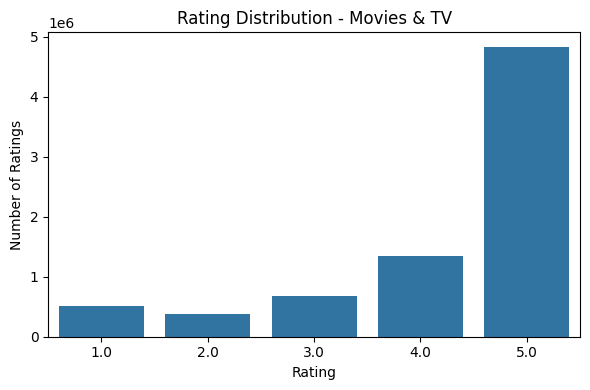

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=movies_ratings,
    x="rating"
)

plt.title("Rating Distribution - Movies & TV")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

### Observation

The rating distributions show how users rate products across the
Games and Movies & TV datasets.

These distributions will help us understand the rating behavior
before building and evaluating the recommendation models.

## 3. User Activity Analysis

We analyze the number of ratings contributed by each user.

This helps us understand user engagement and the distribution of
interaction history available for collaborative filtering.

In [ ]:
games_user_activity = (
    games_ratings
    .groupby("user_id")
    .size()
    .rename("rating_count")
)

movies_user_activity = (
    movies_ratings
    .groupby("user_id")
    .size()
    .rename("rating_count")
)

print("Games:")
print(games_user_activity.describe())

print("\nMovies & TV:")
print(movies_user_activity.describe())

Games:
count    117727.000000
mean          8.196030
std           7.791938
min           1.000000
25%           5.000000
50%           6.000000
75%           9.000000
max         510.000000
Name: rating_count, dtype: float64

Movies & TV:
count    692321.000000
mean         11.176311
std          19.351318
min           1.000000
25%           5.000000
50%           7.000000
75%          11.000000
max        3287.000000
Name: rating_count, dtype: float64


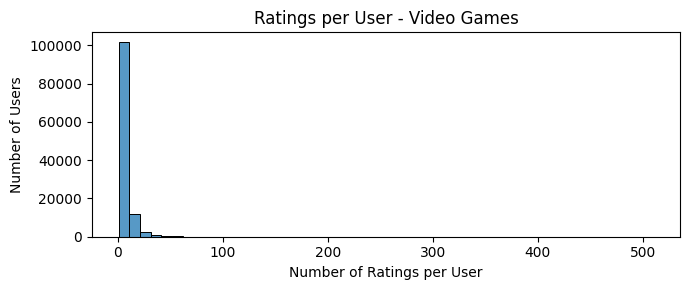

In [ ]:
plt.figure(figsize=(7, 3))

sns.histplot(
    games_user_activity,
    bins=50
)

plt.title("Ratings per User - Video Games")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

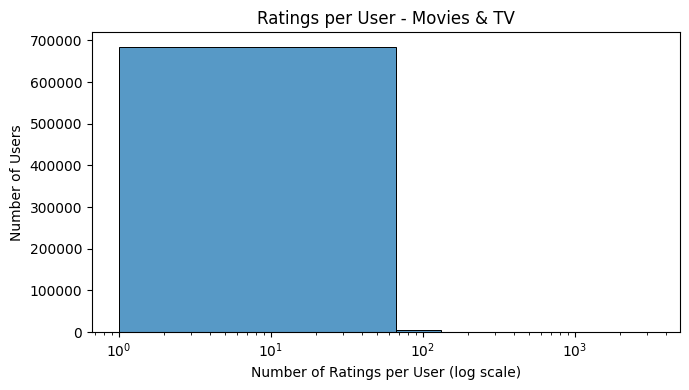

In [ ]:
plt.figure(figsize=(7, 4))

sns.histplot(
    movies_user_activity,
    bins=50
)

plt.xscale("log")

plt.title("Ratings per User - Movies & TV")
plt.xlabel("Number of Ratings per User (log scale)")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 most active Games users:")
display(
    games_user_activity
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 most active Movies & TV users:")
display(
    movies_user_activity
    .sort_values(ascending=False)
    .head(10)
)

Top 10 most active Games users:


user_id
AHJRJCJMK3XVV4BSPBRAHIYEODWA    510
AGMWACNMAG74AXBF7IJ22IOZSZPA    461
AEWLQYBQDYWWUWK6UHHTNWO5AHYA    398
AGIBXD3LM6HNDWWRTIOJHB5EKNFA    360
AHEDJIDSPVYCB3GPRZKGO7YTK6XQ    314
AHY7NSZXW4IUPQ2E4BPUOXUVP3UQ    270
AGKOL2ISXEZE6EIPP5VIINFIHGLQ    246
AENQ4UD7LRPE5DW5BFOTE2UCJRWA    231
AHF2J7WG4CPDF2IOVGZITSHQWFJA    225
AFVOW2EKNL5O25KG6VA4AIZKSB2A    223
Name: rating_count, dtype: int64


Top 10 most active Movies & TV users:


user_id
AGVYDLC4T7LOEVDACAP4FLXN3JNA    3287
AFFYFO6ZXFI74UNJCWAVIU5NLZKA    2397
AGF2CDUUSR2V3YAX5HIENU7REYTA    2326
AGIXTIMXPEXIUXG7Q663I7GMLOTA    2253
AH64MFSCPAUVWZFWIGX55QTI3DVA    2210
AH3FC6V3IUJIN2Y7BCZ7DN3IMMJQ    2129
AEILDB6BUSI7AMDNBXAFCP37CBBA    2028
AHJ3S3V3XBCJZFF7EE4RALKBJPPQ    1524
AFOK3EIUU72VT3UEPRBXPNFCMKIA    1517
AHEDJIDSPVYCB3GPRZKGO7YTK6XQ    1371
Name: rating_count, dtype: int64

### Observation

User activity is not expected to be uniformly distributed.
Some users contribute substantially more interactions than others.

This variation in user activity is important for collaborative
filtering because users with more historical interactions provide
more information for generating recommendations.

## 4. Item Popularity Analysis

We analyze how frequently each item is rated by users.

Item popularity is important in recommendation systems because
frequently interacted items provide a useful baseline for comparing
personalized recommendation methods.

In [ ]:
games_item_popularity = (
    games_ratings
    .groupby("item_id")
    .size()
    .rename("rating_count")
)

movies_item_popularity = (
    movies_ratings
    .groupby("item_id")
    .size()
    .rename("rating_count")
)

print("Games item popularity:")
print(games_item_popularity.describe())

print("\nMovies & TV item popularity:")
print(movies_item_popularity.describe())

Games item popularity:
count    55453.000000
mean        17.400213
std         59.100036
min          1.000000
25%          2.000000
50%          5.000000
75%         12.000000
max       3265.000000
Name: rating_count, dtype: float64

Movies & TV item popularity:
count    285196.000000
mean         27.130798
std         129.921813
min           1.000000
25%           4.000000
50%           8.000000
75%          19.000000
max       19787.000000
Name: rating_count, dtype: float64


In [ ]:
top_games = (
    games_item_popularity
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 most-rated Games items:")
display(top_games)

Top 10 most-rated Games items:


item_id
B01N3ASPNV    3265
B07YBXFDYN    2452
B0086VPUHI    2452
B077GG9D5D    2076
B000N5Z2L4    2003
B00BGA9WK2    1996
B004RMK5QG    1931
B07YBWT3PK    1805
B00C1TTF86    1627
B087NNPYP3    1614
Name: rating_count, dtype: int64

In [ ]:
top_games_df = (
    top_games
    .reset_index()
    .merge(
        games_meta[
            ["item_id", "product_title"]
        ],
        on="item_id",
        how="left"
    )
)

display(top_games_df)

,item_id,rating_count,product_title
0,B01N3ASPNV,3265,amFilm Tempered Glass Screen Protector for Nin...
1,B07YBXFDYN,2452,Skyrim VR - PlayStation 4
2,B0086VPUHI,2452,Grand Theft Auto V: Premium Edition - Xbox One...
3,B077GG9D5D,2076,DualShock 4 Wireless Controller for PlayStatio...
4,B000N5Z2L4,2003,Xbox Live Gold: 1 Month Membership [Digital Code]
5,B00BGA9WK2,1996,PlayStation 4 500GB Console [Old Model][Discon...
6,B004RMK5QG,1931,PlayStation Plus: 12 Month Membership [Digital...
7,B07YBWT3PK,1805,Fallout 4 - Xbox One
8,B00C1TTF86,1627,Battlefield 4 - Playstation 3
9,B087NNPYP3,1614,The Legend of Zelda: Breath of the Wild Master...


In [ ]:
top_movies = (
    movies_item_popularity
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 most-rated Movies & TV items:")
display(top_movies)

Top 10 most-rated Movies & TV items:


item_id
B00I3MQNWG    19787
B00RSGIVVO    19249
B01J4SRJFW    16934
B01AB17IGQ    11801
B003AZCYCE    10134
B00MR9UY8A     9300
B00X8UKOUK     8555
B007SPQZMC     8323
B00RSGHX3Q     8023
B009ZQC7MY     7658
Name: rating_count, dtype: int64

In [ ]:
top_movies_df = (
    top_movies
    .reset_index()
    .merge(
        movies_meta[
            ["item_id", "product_title"]
        ],
        on="item_id",
        how="left"
    )
)

display(top_movies_df)

,item_id,rating_count,product_title
0,B00I3MQNWG,19787,None
1,B00RSGIVVO,19249,None
2,B01J4SRJFW,16934,None
3,B01AB17IGQ,11801,None
4,B003AZCYCE,10134,None
5,B00MR9UY8A,9300,None
6,B00X8UKOUK,8555,None
7,B007SPQZMC,8323,None
8,B00RSGHX3Q,8023,None
9,B009ZQC7MY,7658,None


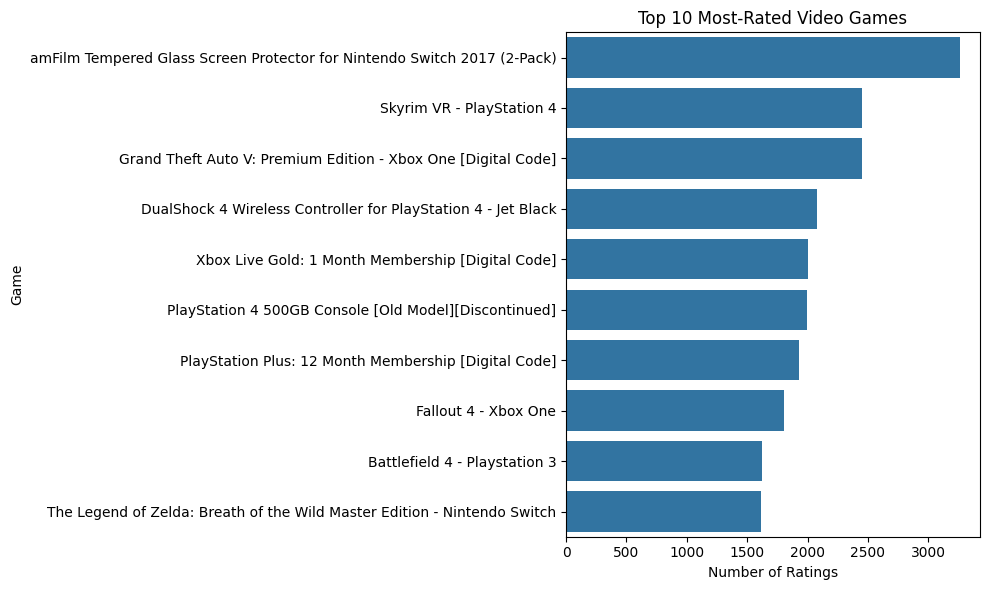

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_games_df,
    x="rating_count",
    y="product_title"
)

plt.title("Top 10 Most-Rated Video Games")
plt.xlabel("Number of Ratings")
plt.ylabel("Game")

plt.tight_layout()
plt.show()

In [ ]:
print(top_movies_df.head(10))

print("\nMissing titles:")
print(top_movies_df["product_title"].isna().sum())

print("\nTotal rows:")
print(len(top_movies_df))

      item_id  rating_count product_title
0  B00I3MQNWG         19787          None
1  B00RSGIVVO         19249          None
2  B01J4SRJFW         16934          None
3  B01AB17IGQ         11801          None
4  B003AZCYCE         10134          None
5  B00MR9UY8A          9300          None
6  B00X8UKOUK          8555          None
7  B007SPQZMC          8323          None
8  B00RSGHX3Q          8023          None
9  B009ZQC7MY          7658          None

Missing titles:
10

Total rows:
10


In [ ]:
print("Movies ratings item_id type:",
      movies_ratings["item_id"].dtype)

print("Movies metadata item_id type:",
      movies_meta["item_id"].dtype)

Movies ratings item_id type: object
Movies metadata item_id type: object


In [ ]:
movies_ratings["item_id"] = movies_ratings["item_id"].astype(str)
movies_meta["item_id"] = movies_meta["item_id"].astype(str)

In [ ]:
top_movies = (
    movies_ratings
    .groupby("item_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_movies_df = (
    top_movies
    .reset_index(name="rating_count")
    .merge(
        movies_meta[["item_id", "product_title"]],
        on="item_id",
        how="left"
    )
)

display(top_movies_df)

,item_id,rating_count,product_title
0,B00I3MQNWG,19787,None
1,B00RSGIVVO,19249,None
2,B01J4SRJFW,16934,None
3,B01AB17IGQ,11801,None
4,B003AZCYCE,10134,None
5,B00MR9UY8A,9300,None
6,B00X8UKOUK,8555,None
7,B007SPQZMC,8323,None
8,B00RSGHX3Q,8023,None
9,B009ZQC7MY,7658,None


In [ ]:
print("Ratings item_id:")
print(movies_ratings["item_id"].dtype)

print("\nMetadata item_id:")
print(movies_meta["item_id"].dtype)

Ratings item_id:
object

Metadata item_id:
object


In [ ]:
print("\nExample rating IDs:")
print(movies_ratings["item_id"].head())

print("\nExample metadata IDs:")
print(movies_meta["item_id"].head())


Example rating IDs:
0    630174411X
1    6302293553
2    0783222068
3    6300184064
4    6303094880
Name: item_id, dtype: object

Example metadata IDs:
0    B009SIYXDA
1    B000RF0V2U
2    B00009N83U
3    B00007FGE5
4    B00GAZ1H1U
Name: item_id, dtype: object


In [ ]:
print("Movies ratings columns:")
print(movies_ratings.columns.tolist())

print("\nMovies metadata columns:")
print(movies_meta.columns.tolist())

Movies ratings columns:
['rating', 'user_id', 'item_id', 'timestamp', 'rating_centered', 'rating_normalized']

Movies metadata columns:
['item_id', 'product_title', 'description', 'price', 'categories']


In [ ]:
print("Number of matching item IDs:")

matching_ids = set(movies_ratings["item_id"]) & set(movies_meta["item_id"])

print(len(matching_ids))
print("Total rating items:", movies_ratings["item_id"].nunique())
print("Total metadata items:", movies_meta["item_id"].nunique())

Number of matching item IDs:
285196
Total rating items: 285196
Total metadata items: 290498


In [ ]:
top_movies_df = (
    top_movies
    .reset_index(name="rating_count")
    .merge(
        movies_meta[["item_id", "product_title"]],
        on="item_id",
        how="left"
    )
)

print(top_movies_df)

      item_id  rating_count product_title
0  B00I3MQNWG         19787          None
1  B00RSGIVVO         19249          None
2  B01J4SRJFW         16934          None
3  B01AB17IGQ         11801          None
4  B003AZCYCE         10134          None
5  B00MR9UY8A          9300          None
6  B00X8UKOUK          8555          None
7  B007SPQZMC          8323          None
8  B00RSGHX3Q          8023          None
9  B009ZQC7MY          7658          None


In [ ]:
print("Missing titles:", top_movies_df["product_title"].isna().sum())

print("\nMetadata for top items:")
display(
    movies_meta[
        movies_meta["item_id"].isin(top_movies.index)
    ][["item_id", "product_title", "description", "categories"]]
)

Missing titles: 10

Metadata for top items:


,item_id,product_title,description,categories
42355,B01AB17IGQ,None,,None
65017,B00RSGHX3Q,None,,None
109729,B009ZQC7MY,None,,None
185016,B01J4SRJFW,None,,None
198182,B00I3MQNWG,None,,None
202532,B00X8UKOUK,None,,None
208399,B007SPQZMC,None,,None
216791,B00MR9UY8A,None,,None
230835,B003AZCYCE,None,,None
276928,B00RSGIVVO,None,,None


,item_id,rating_count,display_title
0,B00I3MQNWG,19787,Item: B00I3MQNWG
1,B00RSGIVVO,19249,Item: B00RSGIVVO
2,B01J4SRJFW,16934,Item: B01J4SRJFW
3,B01AB17IGQ,11801,Item: B01AB17IGQ
4,B003AZCYCE,10134,Item: B003AZCYCE
5,B00MR9UY8A,9300,Item: B00MR9UY8A
6,B00X8UKOUK,8555,Item: B00X8UKOUK
7,B007SPQZMC,8323,Item: B007SPQZMC
8,B00RSGHX3Q,8023,Item: B00RSGHX3Q
9,B009ZQC7MY,7658,Item: B009ZQC7MY


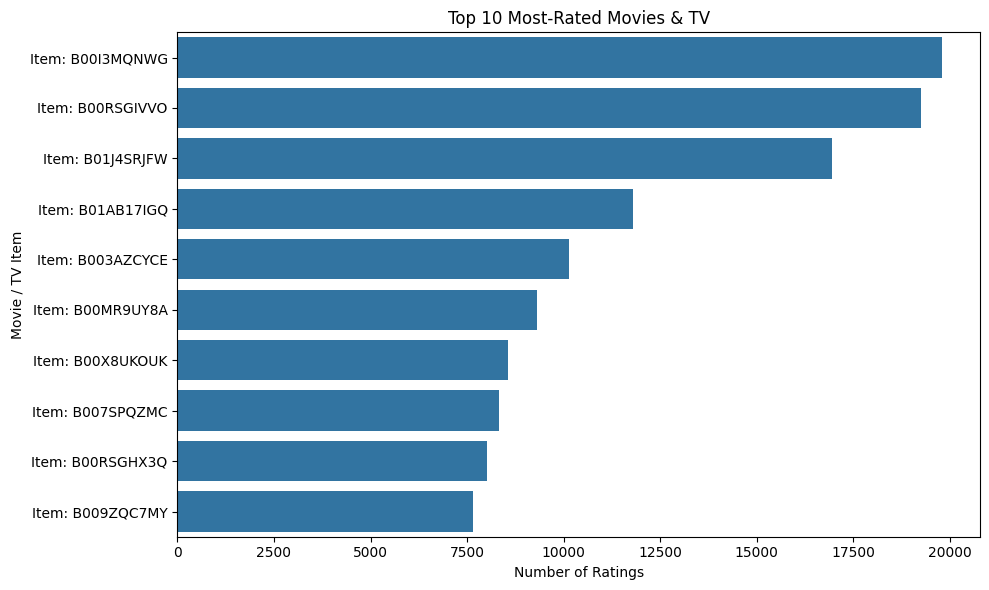

In [ ]:
# Create a display title for plotting
# If the actual movie title is missing, use the item_id instead.

top_movies_df["display_title"] = (
    top_movies_df["product_title"]
    .fillna("Unknown Title")
)

# Replace empty strings as well
top_movies_df.loc[
    top_movies_df["display_title"].astype(str).str.strip() == "",
    "display_title"
] = "Unknown Title"

# For missing titles, show the item ID
missing_mask = top_movies_df["product_title"].isna()

top_movies_df.loc[missing_mask, "display_title"] = (
    "Item: " + top_movies_df.loc[missing_mask, "item_id"]
)

display(top_movies_df[["item_id", "rating_count", "display_title"]])

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_movies_df,
    x="rating_count",
    y="display_title"
)

plt.title("Top 10 Most-Rated Movies & TV")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie / TV Item")

plt.tight_layout()
plt.show()

### Observation

Item popularity is highly variable across the datasets.
Some items receive substantially more interactions than others.

This popularity distribution is relevant when evaluating
recommendation models because popular-item recommendations can
perform differently from personalized recommendations.

## 5. Dataset Sparsity Analysis

Recommendation datasets are usually sparse because users interact with
only a small fraction of the available items.

Sparsity measures the proportion of user-item combinations for which
no rating or interaction exists.

In [ ]:
games_users = games_ratings["user_id"].nunique()
games_items = games_ratings["item_id"].nunique()
games_interactions = len(games_ratings)

games_sparsity = (
    1 - games_interactions / (games_users * games_items)
)

movies_users = movies_ratings["user_id"].nunique()
movies_items = movies_ratings["item_id"].nunique()
movies_interactions = len(movies_ratings)

movies_sparsity = (
    1 - movies_interactions / (movies_users * movies_items)
)

print(f"Games sparsity: {games_sparsity:.6%}")
print(f"Movies & TV sparsity: {movies_sparsity:.6%}")

Games sparsity: 99.985220%
Movies & TV sparsity: 99.996081%


In [ ]:
sparsity_df = pd.DataFrame({
    "Dataset": ["Games", "Movies & TV"],
    "Users": [games_users, movies_users],
    "Items": [games_items, movies_items],
    "Interactions": [games_interactions, movies_interactions],
    "Sparsity": [games_sparsity, movies_sparsity]
})

display(sparsity_df)

,Dataset,Users,Items,Interactions,Sparsity
0,Games,117727,55453,964894,0.999852
1,Movies & TV,692321,285196,7737595,0.999961


### Observation

Both datasets are highly sparse, meaning that users interact with only
a small fraction of the available items.

This sparsity is an important characteristic of recommendation systems
and motivates the use of collaborative filtering and other
recommendation techniques.

## 6. Train/Test Dataset Analysis

The cleaned datasets are divided into training and testing sets using
a time-based split.

The training set contains earlier user interactions, while the testing
set contains later interactions.

This allows recommendation models to be evaluated on future-like
interactions rather than randomly shuffled data.

In [ ]:
games_train = pd.read_parquet(
    PROCESSED_DIR / "games_train.parquet"
)

games_test = pd.read_parquet(
    PROCESSED_DIR / "games_test.parquet"
)

movies_train = pd.read_parquet(
    PROCESSED_DIR / "movies_train.parquet"
)

movies_test = pd.read_parquet(
    PROCESSED_DIR / "movies_test.parquet"
)

print("Games train:", games_train.shape)
print("Games test :", games_test.shape)

print("Movies train:", movies_train.shape)
print("Movies test :", movies_test.shape)

Games train: (783871, 6)
Games test : (181023, 6)
Movies train: (6242205, 6)
Movies test : (1495390, 6)


In [ ]:
games_test_only_users = (
    set(games_test["user_id"]) - set(games_train["user_id"])
)

movies_test_only_users = (
    set(movies_test["user_id"]) - set(movies_train["user_id"])
)

print("Games test-only users:", len(games_test_only_users))
print("Movies & TV test-only users:", len(movies_test_only_users))

Games test-only users: 0
Movies & TV test-only users: 0


In [ ]:
split_summary = pd.DataFrame({
    "Dataset": ["Games", "Movies & TV"],
    "Train Interactions": [
        len(games_train),
        len(movies_train)
    ],
    "Test Interactions": [
        len(games_test),
        len(movies_test)
    ]
})

split_summary["Test Percentage"] = (
    split_summary["Test Interactions"]
    / (split_summary["Train Interactions"] + split_summary["Test Interactions"])
    * 100
)

display(split_summary)

,Dataset,Train Interactions,Test Interactions,Test Percentage
0,Games,783871,181023,18.760921
1,Movies & TV,6242205,1495390,19.326289


## 7. Games vs Movies & TV Comparison

This section compares the Games and Movies & TV datasets based on
users, items, interactions, average ratings, and sparsity.

The comparison helps us understand the differences between the two
domains before applying recommendation algorithms.

In [ ]:
comparison_df = pd.DataFrame({
    "Dataset": ["Games", "Movies & TV"],
    "Users": [
        games_ratings["user_id"].nunique(),
        movies_ratings["user_id"].nunique()
    ],
    "Items": [
        games_ratings["item_id"].nunique(),
        movies_ratings["item_id"].nunique()
    ],
    "Interactions": [
        len(games_ratings),
        len(movies_ratings)
    ],
    "Average Rating": [
        games_ratings["rating"].mean(),
        movies_ratings["rating"].mean()
    ],
    "Sparsity": [
        games_sparsity,
        movies_sparsity
    ]
})

display(comparison_df)

,Dataset,Users,Items,Interactions,Average Rating,Sparsity
0,Games,117727,55453,964894,4.250247,0.999852
1,Movies & TV,692321,285196,7737595,4.243632,0.999961


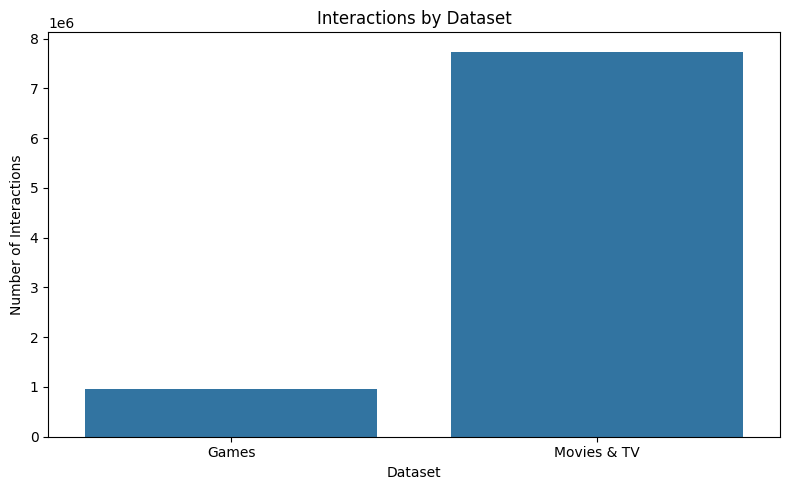

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="Dataset",
    y="Interactions"
)

plt.title("Interactions by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Interactions")

plt.tight_layout()
plt.show()

### EDA Summary

The exploratory analysis shows that both datasets contain a large
number of users, items, and user-item interactions.

Both datasets are highly sparse, with most possible user-item
combinations having no interaction.

The Games and Movies & TV datasets also show differences in their
number of users, items, and interactions.

These characteristics provide the foundation for applying
collaborative filtering, content-based recommendation, and hybrid
recommendation approaches.

## 8. Global Mean Baseline

The Global Mean Baseline predicts the same rating for every user-item
pair.

The prediction is calculated as the average rating in the training
dataset.

This simple baseline provides a reference point for evaluating more
advanced recommendation models.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def compute_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def evaluate_baseline_global_mean(train_ratings_df, test_ratings_df):
    """
    Evaluate a Global Mean baseline.

    The model predicts the average training rating
    for every test interaction.
    """

    global_mean = train_ratings_df["rating"].mean()

    y_true = test_ratings_df["rating"].values
    y_pred = np.full(len(y_true), global_mean)

    rmse = compute_rmse(y_true, y_pred)
    mae = compute_mae(y_true, y_pred)

    print(f"Global mean rating: {global_mean:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")

    return rmse, mae

# User-Based Collaborative Filtering

User-Based Collaborative Filtering recommends items by finding users
with similar rating behavior and using their preferences to generate
recommendations.

In [ ]:
import models.collaborative_filtering.collaborative_filtering as cf

print([name for name in dir(cf) if "user_cf" in name])

ModuleNotFoundError: No module named 'models'

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "amazon-recommendation-system":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model,
    get_similar_users,
    predict_rating_user_cf,
    recommend_items_user_cf,
    CF_N_NEIGHBORS
)

In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model,
    get_similar_users,
    predict_rating_user_cf,
    recommend_items_user_cf,
    CF_N_NEIGHBORS
)

print("Collaborative Filtering module imported successfully!")

Collaborative Filtering module imported successfully!


In [ ]:
import pandas as pd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

games_train = pd.read_parquet(
    PROCESSED_DIR / "games_train.parquet"
)

games_meta = pd.read_parquet(
    PROCESSED_DIR / "games_clean_meta.parquet"
)

print("Games training data:", games_train.shape)
print("Games metadata:", games_meta.shape)

Games training data: (783871, 6)
Games metadata: (63180, 5)


In [ ]:
games_user_cf = build_user_cf_model(
    games_train,
    n_neighbors=CF_N_NEIGHBORS
)

print("Games User-Based CF model built successfully!")

Games User-Based CF model built successfully!


In [ ]:
test_user_id = games_train["user_id"].iloc[0]

print("Test User ID:", test_user_id)

Test User ID: AE222HFZDH6BPTYFOUWGGU63YSIQ


In [ ]:
similar_users, distances = get_similar_users(
    games_user_cf,
    test_user_id,
    n_neighbors=15
)

print("Similar user indices:")
print(similar_users)

print("\nCosine distances:")
print(distances)

Similar user indices:
[   414  25646  64966  43648  64004  12496  23453  23344  27242 106531
  12007  94835  24813  60474  66382]

Cosine distances:
[0.6        0.627322   0.6619383  0.68991316 0.68991316 0.69285244
 0.70382556 0.70382556 0.71132487 0.71132487 0.71132487 0.73462755
 0.74180111 0.74180111 0.74180111]


In [ ]:
similar_user_ids = games_user_cf["user_encoder"].inverse_transform(
    similar_users
)

similarities = 1 - distances

similar_users_df = pd.DataFrame({
    "user_id": similar_user_ids,
    "similarity": similarities
})

similar_users_df

,user_id,similarity
0,AE2I3ANXQKHBQUYUJ4QLPENEKHSQ,0.400000
1,AEVN5SXA4ID45EHIHNPO4ECT7PJA,0.372678
2,AGAUTRQ4CYKTKRSNQ5WXASA5TVGA,0.338062
3,AFJHZ4RM6VWYHOJNSB7XAZYDK3OQ,0.310087
4,AG7U72DHD46E7UUJZZWFUDRQDTPA,0.310087
5,AEHLD6II7ZHLB2AWCCFYSLUE767Q,0.307148
6,AETDGQEASOUEFPCTDIQ2OF5YHI5A,0.296174
7,AETA3KW75T45SZFZAF2C365B3WIA,0.296174
8,AEXFLQIGDOMOKZ65CIONRQABMZOA,0.288675
9,AHNY6AGETAWQXLIF7OU3QJ2SLMRA,0.288675


In [ ]:
rated_items = set(
    games_train.loc[
        games_train["user_id"] == test_user_id,
        "item_id"
    ]
)

candidate_item = games_train[
    ~games_train["item_id"].isin(rated_items)
]["item_id"].iloc[0]

print("Test User:", test_user_id)
print("Candidate Item:", candidate_item)

Test User: AE222HFZDH6BPTYFOUWGGU63YSIQ
Candidate Item: B0050SX4CI


In [ ]:
predicted_rating = predict_rating_user_cf(
    games_user_cf,
    games_train,
    test_user_id,
    candidate_item
)

print("Predicted Rating:", predicted_rating)

Predicted Rating: None


In [ ]:
similar_user_ids = games_user_cf["user_encoder"].inverse_transform(
    similar_users
)

similar_user_ratings = games_train[
    games_train["user_id"].isin(similar_user_ids)
]

print("Ratings from similar users:", len(similar_user_ratings))

Ratings from similar users: 62


In [ ]:
candidate_item = (
    similar_user_ratings["item_id"]
    .value_counts()
    .index[0]
)

print("Candidate Item:", candidate_item)

Candidate Item: B01GY35T4S


In [ ]:
user_rated_items = set(
    games_train.loc[
        games_train["user_id"] == test_user_id,
        "item_id"
    ]
)

print("Already rated:", candidate_item in user_rated_items)

Already rated: True


In [ ]:
user_rated_items = set(
    games_train.loc[
        games_train["user_id"] == test_user_id,
        "item_id"
    ]
)

candidate_items = (
    similar_user_ratings[
        ~similar_user_ratings["item_id"].isin(user_rated_items)
    ]["item_id"]
    .value_counts()
)

print("Candidate items available:", len(candidate_items))

Candidate items available: 46


In [ ]:
candidate_item = candidate_items.index[0]

print("Test User:", test_user_id)
print("Candidate Item:", candidate_item)

Test User: AE222HFZDH6BPTYFOUWGGU63YSIQ
Candidate Item: B07DKZ9K13


In [ ]:
recommendations = recommend_items_user_cf(
    user_cf_data=games_user_cf,
    train_ratings_df=games_train,
    metadata_df=games_meta,
    user_id=test_user_id,
    top_n=10
)

recommendations

,item_id,product_title,score
0,B00GYIM37A,Microsoft Xbox Live 12 Month Gold Card,5.0
1,B009NRO1J2,Wii U Precision Screen Filter,5.0
2,B002BSC5HA,Lego Harry Potter: Years 1-4 - Nintendo DS,5.0
3,B01N5T26EP,Game Traveler Zelda Nintendo Switch Case - Swi...,5.0
4,B075YBBQMM,"PS4 Controller Charger Dock Station, OIVO PS4 ...",5.0
5,B079FPFV3X,OIVO PS4 Stand Cooling Fan Station for Playsta...,5.0
6,B077GG9D5D,DualShock 4 Wireless Controller for PlayStatio...,5.0
7,B01M4M9E2C,Xbox One Elite Wireless Controller (Renewed),5.0
8,B01N1P0KFI,Amazon Basics Dual Charging Station for Xbox O...,5.0
9,B01GW3H3U8,Xbox Wireless Controller – White,5.0


In [ ]:
print("Number of recommendations:", len(recommendations))

Number of recommendations: 10


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "amazon-recommendation-system":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Lenovo\amazon-recommendation-system


In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model,
    get_similar_users,
    predict_rating_user_cf,
    recommend_items_user_cf,
    build_item_cf_model,
    get_similar_items,
    CF_N_NEIGHBORS
)

In [ ]:
games_item_cf = build_item_cf_model(
    games_train,
    n_neighbors=CF_N_NEIGHBORS
)

print("Games Item-Based CF model built successfully!")

Games Item-Based CF model built successfully!


In [ ]:
test_item_id = games_train["item_id"].iloc[0]

print("Test Item ID:", test_item_id)

Test Item ID: B082R1RGZF


In [ ]:
similar_items, item_distances = get_similar_items(
    games_item_cf,
    test_item_id,
    n_neighbors=10
)

print("Similar item indices:")
print(similar_items)

print("\nCosine distances:")
print(item_distances)

Similar item indices:
[33751 29828 35215 49837 25020 31411 37753 35924 34798 40703]

Cosine distances:
[0.81518273 0.81985929 0.83842514 0.84618173 0.85498953 0.8610952
 0.86655227 0.88100296 0.88581499 0.88837089]


In [ ]:
similar_item_ids = games_item_cf["item_encoder"].inverse_transform(
    similar_items
)

item_similarities = 1 - item_distances

similar_items_df = pd.DataFrame({
    "item_id": similar_item_ids,
    "similarity": item_similarities
})

similar_items_df

,item_id,similarity
0,B07CLZMCYK,0.184817
1,B06WLMX6N5,0.180141
2,B07H2BHLGX,0.161575
3,B0B789RDJZ,0.153818
4,B00YY3P5WW,0.145010
5,B073X4RGFP,0.138905
6,B07RDR7B3D,0.133448
7,B07KC76Y8Z,0.118997
8,B07FYY6SCF,0.114185
9,B083VY4B7F,0.111629


In [ ]:
from pathlib import Path

file_path = PROJECT_ROOT / "models" / "collaborative_filtering" / "collaborative_filtering.py"

print(file_path)
print(file_path.exists())

c:\Users\Lenovo\amazon-recommendation-system\models\collaborative_filtering\collaborative_filtering.py
True


In [ ]:
content = file_path.read_text(encoding="utf-8")

print("recommend_items_item_cf" in content)

True


In [ ]:
for line_number, line in enumerate(content.splitlines(), start=1):
    if "recommend_items_item_cf" in line:
        print(line_number, line)

426 def recommend_items_item_cf(


In [ ]:

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "amazon-recommendation-system":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    recommend_items_item_cf
)

print("Import successful!")

Import successful!


In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model,
    get_similar_users,
    predict_rating_user_cf,
    recommend_items_user_cf,
    build_item_cf_model,
    get_similar_items,
    recommend_items_item_cf,
    CF_N_NEIGHBORS
)

print("All Collaborative Filtering functions imported successfully!")

All Collaborative Filtering functions imported successfully!


In [ ]:
item_recommendations = recommend_items_item_cf(
    item_cf_data=games_item_cf,
    train_ratings_df=games_train,
    metadata_df=games_meta,
    user_id=test_user_id,
    top_n=10
)

item_recommendations

,item_id,product_title,score
0,B09GV6RNNR,SteelSeries Level Up Gaming Bundle,1.666667
1,B09V2RBL2B,HyperX Clutch – Gaming Controller for Android ...,1.333333
2,B0C6JQYCVZ,abucow 60% Mechanical Keyboard Wired RGB Hot S...,1.333333
3,B0B2DMYYBZ,Bloody P81s Optical Gaming Mouse with Light St...,1.178511
4,B09Z5Z8JJF,"RedThunder K84 Wired Gaming Keyboard, 75% Ultr...",0.942809
5,B07QVK82XP,RGEEK 512MB High Speed Game Memory Card Compat...,0.927199
6,B07CLZMCYK,Talentech Ember Plus Ergonomic RGB USB Wired G...,0.924086
7,B07WR3Z69K,"2 Pack USB N64 Controller, iNNEXT N64 Wired PC...",0.909193
8,B06WLMX6N5,PowerA Fusion Wired Stereo Gaming Headset with...,0.900704
9,B0B9N61YYG,Keruixin Kickstand Protective Case for Steam D...,0.832927


In [ ]:
recommended_ids = set(item_recommendations["item_id"])

user_rated_items = set(
    games_train.loc[
        games_train["user_id"] == test_user_id,
        "item_id"
    ]
)

print(
    "Already-rated items recommended:",
    len(recommended_ids & user_rated_items)
)

Already-rated items recommended: 0


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error


def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def compute_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

In [ ]:
def evaluate_global_mean(train_df, test_df):
    global_mean = train_df["rating"].mean()

    y_true = test_df["rating"].values
    y_pred = np.full(
        len(y_true),
        global_mean
    )

    rmse = compute_rmse(y_true, y_pred)
    mae = compute_mae(y_true, y_pred)

    return {
        "Model": "Global Mean",
        "RMSE": rmse,
        "MAE": mae
    }

In [ ]:
global_mean_result = evaluate_global_mean(
    games_train,
    games_test
)

global_mean_result

{'Model': 'Global Mean',
 'RMSE': np.float64(1.272233203139948),
 'MAE': 0.9937682491141261}

In [ ]:
EVAL_SAMPLE_SIZE = 500
games_test_sample = games_test.sample(
    n=EVAL_SAMPLE_SIZE,
    random_state=42
)

print(
    "Evaluation sample:",
    games_test_sample.shape
)

Evaluation sample: (500, 6)


In [ ]:
import pandas as pd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

games_train = pd.read_parquet(
    PROCESSED_DIR / "games_train.parquet"
)

games_test = pd.read_parquet(
    PROCESSED_DIR / "games_test.parquet"
)

games_meta = pd.read_parquet(
    PROCESSED_DIR / "games_clean_meta.parquet"
)

print("Training:", games_train.shape)
print("Test:", games_test.shape)

Training: (783871, 6)
Test: (181023, 6)


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "amazon-recommendation-system":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Models folder exists:", (PROJECT_ROOT / "models").exists())

Project root: c:\Users\Lenovo\amazon-recommendation-system
Models folder exists: True


In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model,
    get_similar_users,
    predict_rating_user_cf,
    recommend_items_user_cf,
    build_item_cf_model,
    get_similar_items,
    recommend_items_item_cf,
    predict_rating_item_cf,
    CF_N_NEIGHBORS
)

print("All Collaborative Filtering functions imported successfully!")

All Collaborative Filtering functions imported successfully!


In [ ]:
def evaluate_user_cf(
    user_cf_data,
    train_df,
    test_df,
    sample_size=500
):
    """
    Evaluate User-Based Collaborative Filtering
    using a sample of the test set.
    """

    sample = test_df.sample(
        n=min(sample_size, len(test_df)),
        random_state=42
    )

    y_true = []
    y_pred = []

    for _, row in sample.iterrows():

        prediction = predict_rating_user_cf(
            user_cf_data,
            train_df,
            row["user_id"],
            row["item_id"]
        )

        if prediction is not None:

            y_true.append(row["rating"])
            y_pred.append(prediction)

    if len(y_true) == 0:
        return None

    rmse = compute_rmse(
        y_true,
        y_pred
    )

    mae = compute_mae(
        y_true,
        y_pred
    )

    return {
        "Model": "User-Based CF",
        "RMSE": rmse,
        "MAE": mae,
        "Evaluated Samples": len(y_true)
    }

In [ ]:
import pandas as pd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

games_train = pd.read_parquet(
    PROCESSED_DIR / "games_train.parquet"
)

games_test = pd.read_parquet(
    PROCESSED_DIR / "games_test.parquet"
)

games_meta = pd.read_parquet(
    PROCESSED_DIR / "games_clean_meta.parquet"
)

print("Training:", games_train.shape)
print("Test:", games_test.shape)
print("Metadata:", games_meta.shape)

Training: (783871, 6)
Test: (181023, 6)
Metadata: (63180, 5)


In [ ]:
games_user_cf = build_user_cf_model(
    games_train,
    n_neighbors=CF_N_NEIGHBORS
)

games_item_cf = build_item_cf_model(
    games_train,
    n_neighbors=CF_N_NEIGHBORS
)

print("User-CF model ready.")
print("Item-CF model ready.")

User-CF model ready.
Item-CF model ready.


In [ ]:
user_cf_result = evaluate_user_cf(
    games_user_cf,
    games_train,
    games_test,
    sample_size=EVAL_SAMPLE_SIZE
)

user_cf_result

{'Model': 'User-Based CF',
 'RMSE': np.float64(2.0634487548687677),
 'MAE': 1.4940755575581244,
 'Evaluated Samples': 51}

In [ ]:
def evaluate_item_cf(
    item_cf_data,
    train_df,
    test_df,
    sample_size=500
):
    """
    Evaluate Item-Based Collaborative Filtering
    on a sample of the test set.
    """

    sample = test_df.sample(
        n=min(sample_size, len(test_df)),
        random_state=42
    )

    y_true = []
    y_pred = []

    for _, row in sample.iterrows():

        prediction = predict_rating_item_cf(
            item_cf_data,
            train_df,
            row["user_id"],
            row["item_id"]
        )

        if prediction is not None:
            y_true.append(row["rating"])
            y_pred.append(prediction)

    if len(y_true) == 0:
        return None

    return {
        "Model": "Item-Based CF",
        "RMSE": compute_rmse(y_true, y_pred),
        "MAE": compute_mae(y_true, y_pred),
        "Evaluated Samples": len(y_true)
    }

In [ ]:
def predict_rating_item_cf(
    item_cf_data,
    train_ratings_df,
    user_id,
    item_id,
    n_neighbors=CF_N_NEIGHBORS
):
    """
    Predict a user's rating for an item using
    similar items.
    """

    item_encoder = item_cf_data["item_encoder"]

    if item_id not in item_encoder.classes_:
        return None

    user_ratings = train_ratings_df[
        train_ratings_df["user_id"] == user_id
    ][["item_id", "rating"]]

    if user_ratings.empty:
        return None

    if item_id in set(user_ratings["item_id"]):
        return None

    weighted_sum = 0.0
    similarity_sum = 0.0

    for _, row in user_ratings.iterrows():

        rated_item = row["item_id"]
        rating = row["rating"]

        if rated_item not in item_encoder.classes_:
            continue

        similar_items, distances = get_similar_items(
            item_cf_data,
            rated_item,
            n_neighbors=n_neighbors
        )

        similarities = 1 - distances

        similar_item_ids = item_encoder.inverse_transform(
            similar_items
        )

        matches = np.where(
            similar_item_ids == item_id
        )[0]

        if len(matches) == 0:
            continue

        similarity = similarities[matches[0]]

        weighted_sum += similarity * rating
        similarity_sum += similarity

    if similarity_sum == 0:
        return None

    return float(
        weighted_sum / similarity_sum
    )

In [ ]:
item_cf_result = evaluate_item_cf(
    games_item_cf,
    games_train,
    games_test,
    sample_size=500
)

print(item_cf_result)

{'Model': 'Item-Based CF', 'RMSE': np.float64(1.2341637848541789), 'MAE': 0.6112760932592028, 'Evaluated Samples': 61}


In [ ]:
user_coverage = 51 / 500
item_coverage = 61 / 500

print(f"User-CF Coverage : {user_coverage:.2%}")
print(f"Item-CF Coverage : {item_coverage:.2%}")

User-CF Coverage : 10.20%
Item-CF Coverage : 12.20%


In [ ]:
def precision_at_k(recommended_items, relevant_items, k=10):
    """
    Calculate Precision@K.

    recommended_items: ordered list of recommended item IDs
    relevant_items: set of relevant item IDs
    """

    recommended_items = recommended_items[:k]

    if len(recommended_items) == 0:
        return 0.0

    hits = sum(
        item in relevant_items
        for item in recommended_items
    )

    return hits / len(recommended_items)

In [ ]:
def evaluate_precision_at_10(
    recommendation_function,
    model_data,
    train_df,
    test_df,
    metadata_df,
    sample_users=100
):
    """
    Evaluate Precision@10 for a recommendation model.

    A test item is considered relevant when its rating >= 4.
    """

    # Users who appear in the test set
    test_users = test_df["user_id"].unique()

    # Sample users to keep computation manageable
    rng = np.random.RandomState(42)

    selected_users = rng.choice(
        test_users,
        size=min(sample_users, len(test_users)),
        replace=False
    )

    precisions = []
    evaluated_users = 0

    for user_id in selected_users:

        # Relevant items from the TEST set
        relevant_items = set(
            test_df.loc[
                (test_df["user_id"] == user_id)
                & (test_df["rating"] >= 4),
                "item_id"
            ]
        )

        if len(relevant_items) == 0:
            continue

        recommendations = recommendation_function(
            model_data,
            train_df,
            metadata_df,
            user_id=user_id,
            top_n=10
        )

        if recommendations.empty:
            continue

        recommended_items = (
            recommendations["item_id"]
            .tolist()
        )

        precision = precision_at_k(
            recommended_items,
            relevant_items,
            k=10
        )

        precisions.append(precision)
        evaluated_users += 1

    if len(precisions) == 0:
        return None

    return {
        "Precision@10": np.mean(precisions),
        "Evaluated Users": evaluated_users
    }

In [ ]:
user_cf_precision = evaluate_precision_at_10(
    recommendation_function=recommend_items_user_cf,
    model_data=games_user_cf,
    train_df=games_train,
    test_df=games_test,
    metadata_df=games_meta,
    sample_users=100
)

print(user_cf_precision)

{'Precision@10': np.float64(0.005681818181818182), 'Evaluated Users': 88}


In [ ]:
item_cf_precision = evaluate_precision_at_10(
    recommendation_function=recommend_items_item_cf,
    model_data=games_item_cf,
    train_df=games_train,
    test_df=games_test,
    metadata_df=games_meta,
    sample_users=100
)

print(item_cf_precision)

{'Precision@10': np.float64(0.00681818181818182), 'Evaluated Users': 88}


In [ ]:
evaluation_results = pd.DataFrame([
    {
        "Model": "User-Based CF",
        "RMSE": float(user_cf_result["RMSE"]),
        "MAE": float(user_cf_result["MAE"]),
        "Precision@10": float(user_cf_precision["Precision@10"]),
        "Evaluated Samples": user_cf_result["Evaluated Samples"],
        "Evaluated Users": user_cf_precision["Evaluated Users"]
    },
    {
        "Model": "Item-Based CF",
        "RMSE": float(item_cf_result["RMSE"]),
        "MAE": float(item_cf_result["MAE"]),
        "Precision@10": float(item_cf_precision["Precision@10"]),
        "Evaluated Samples": item_cf_result["Evaluated Samples"],
        "Evaluated Users": item_cf_precision["Evaluated Users"]
    }
])

evaluation_results

,Model,RMSE,MAE,Precision@10,Evaluated Samples,Evaluated Users
0,User-Based CF,2.063449,1.494076,0.005682,51,88
1,Item-Based CF,1.234164,0.611276,0.006818,61,88


In [ ]:
from models.matrix_factorization.matrix_factorization import build_svd_model

In [ ]:
svd_model = build_svd_model(
    games_train,
    n_factors=50,
    n_epochs=20
)

print("SVD model trained successfully.")

SVD model trained successfully.


In [ ]:
import importlib
import models.matrix_factorization.matrix_factorization as mf

importlib.reload(mf)

<module 'models.matrix_factorization.matrix_factorization' from 'c:\\Users\\Lenovo\\amazon-recommendation-system\\models\\matrix_factorization\\matrix_factorization.py'>

In [ ]:
from models.matrix_factorization.matrix_factorization import (
    build_svd_model,
    predict_rating_svd
)

In [ ]:
sample = games_test.iloc[0]

user_id = sample["user_id"]
item_id = sample["item_id"]
actual_rating = sample["rating"]

predicted_rating = predict_rating_svd(
    svd_model,
    user_id,
    item_id
)

print("User ID:", user_id)
print("Item ID:", item_id)
print("Actual Rating:", actual_rating)
print("Predicted Rating:", round(predicted_rating, 4))

User ID: AE222HFZDH6BPTYFOUWGGU63YSIQ
Item ID: B0BJVLBNCP
Actual Rating: 5.0
Predicted Rating: 4.5968


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    build_svd_model,
    predict_rating_svd,
    evaluate_svd
)

In [ ]:
svd_results = evaluate_svd(
    svd_model,
    games_test,
    sample_size=500
)

print(svd_results)

{'Model': 'SVD', 'RMSE': np.float64(1.2166320073727546), 'MAE': 0.8844764143896374, 'Evaluated Samples': 500}


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    build_svd_model,
    predict_rating_svd,
    evaluate_svd,
    recommend_items_svd
)

In [ ]:
test_user = games_test["user_id"].iloc[0]

print("Test User:", test_user)

Test User: AE222HFZDH6BPTYFOUWGGU63YSIQ


In [ ]:
svd_recommendations = recommend_items_svd(
    svd_model,
    games_train,
    games_meta,
    user_id=test_user,
    top_n=10
)

svd_recommendations

,item_id,product_title,score
0,B0BGFJC9KR,PS5 Faceplate with Cooling Vent Face Plate Con...,5.0
1,B002AU0HZQ,Professor Layton and the Diabolical Box,5.0
2,B000M6DHA2,SanDisk Wii 2GB Secure Digital SD Gaming Memor...,5.0
3,B0BX7NC5K1,The Legend of Zelda: Tears of the Kingdom - Ni...,5.0
4,B00004SA3J,Visual Memory Unit - Blue,5.0
5,B0000A1VER,Far Cry - PC,5.0
6,B07VTR7B18,"Redragon K503 PC Gaming Keyboard, Wired, Multi...",5.0
7,B01MTJRD4D,Super Stardust Ultra VR PS4 Game (PSVR Compati...,5.0
8,B00002SVBA,X-COM: UFO Defense - PlayStation,5.0
9,B08F4C6HCD,Legend of Zelda Link's Awakening - Nintendo Sw...,5.0


In [ ]:
print(svd_recommendations["score"].describe())

count    10.0
mean      5.0
std       0.0
min       5.0
25%       5.0
50%       5.0
75%       5.0
max       5.0
Name: score, dtype: float64


In [ ]:
print(
    svd_recommendations["score"].value_counts().head(20)
)

score
5.0    10
Name: count, dtype: int64


In [ ]:
candidate_scores = []

user_id = test_user

user_rated_items = set(
    games_train.loc[
        games_train["user_id"] == user_id,
        "item_id"
    ]
)

candidate_items = games_meta[
    ~games_meta["item_id"].isin(user_rated_items)
]["item_id"]

for item_id in candidate_items:
    prediction = svd_model.predict(
        user_id,
        item_id
    )

    candidate_scores.append(prediction.est)

candidate_scores = np.array(candidate_scores)

print("Number of candidate items:", len(candidate_scores))
print("Minimum prediction:", candidate_scores.min())
print("Maximum prediction:", candidate_scores.max())
print("Mean prediction:", candidate_scores.mean())
print("Predictions equal to 5.0:", np.sum(candidate_scores == 5.0))

Number of candidate items: 63175
Minimum prediction: 2.376441367152228
Maximum prediction: 5.0
Mean prediction: 4.575903001566766
Predictions equal to 5.0: 1384


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    evaluate_svd_precision_at_10
)

In [ ]:
svd_precision = evaluate_svd_precision_at_10(
    svd_model,
    games_train,
    games_test,
    games_meta,
    sample_users=100
)

print(svd_precision)

{'Model': 'SVD', 'Precision@10': np.float64(0.0), 'Evaluated Users': 88}


In [ ]:
user_id = test_user

actual_test_items = games_test[
    games_test["user_id"] == user_id
][["item_id", "rating"]].sort_values(
    "rating",
    ascending=False
)

print("Actual test items:")
print(actual_test_items.head(20))

Actual test items:
      item_id  rating
0  B0BJVLBNCP     5.0


In [ ]:
print("SVD recommendations:")
print(svd_recommendations)

SVD recommendations:
      item_id                                      product_title  score
0  B0BGFJC9KR  PS5 Faceplate with Cooling Vent Face Plate Con...    5.0
1  B002AU0HZQ            Professor Layton and the Diabolical Box    5.0
2  B000M6DHA2  SanDisk Wii 2GB Secure Digital SD Gaming Memor...    5.0
3  B0BX7NC5K1  The Legend of Zelda: Tears of the Kingdom - Ni...    5.0
4  B00004SA3J                          Visual Memory Unit - Blue    5.0
5  B0000A1VER                                       Far Cry - PC    5.0
6  B07VTR7B18  Redragon K503 PC Gaming Keyboard, Wired, Multi...    5.0
7  B01MTJRD4D  Super Stardust Ultra VR PS4 Game (PSVR Compati...    5.0
8  B00002SVBA                   X-COM: UFO Defense - PlayStation    5.0
9  B08F4C6HCD  Legend of Zelda Link's Awakening - Nintendo Sw...    5.0


In [ ]:
from surprise import NMF

print("NMF imported successfully")

NMF imported successfully


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    build_nmf_model
)

In [ ]:
nmf_model = build_nmf_model(
    games_train,
    n_factors=50,
    n_epochs=20
)

print("NMF model trained successfully.")

NMF model trained successfully.


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    predict_rating_nmf
)

In [ ]:
sample = games_test.iloc[0]

user_id = sample["user_id"]
item_id = sample["item_id"]
actual_rating = sample["rating"]

predicted_rating = predict_rating_nmf(
    nmf_model,
    user_id,
    item_id
)

print("User ID:", user_id)
print("Item ID:", item_id)
print("Actual Rating:", actual_rating)
print("Predicted Rating:", round(predicted_rating, 4))

User ID: AE222HFZDH6BPTYFOUWGGU63YSIQ
Item ID: B0BJVLBNCP
Actual Rating: 5.0
Predicted Rating: 4.2614


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    evaluate_nmf
)

In [ ]:
nmf_results = evaluate_nmf(
    nmf_model,
    games_test,
    sample_size=500
)

print(nmf_results)

{'Model': 'NMF', 'RMSE': np.float64(1.4312724421554648), 'MAE': 0.7750960437505289, 'Evaluated Samples': 500}


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    recommend_items_nmf
)

In [ ]:
nmf_recommendations = recommend_items_nmf(
    nmf_model,
    games_train,
    games_meta,
    user_id=test_user,
    top_n=10
)

nmf_recommendations

,item_id,product_title,score
0,B0C2V4Y8G8,"IINE Switch Controller, Wireless Switch Pro Co...",5.0
1,B00069EVOG,Phantasmagoria: A Puzzle of Flesh,5.0
2,B00Z9TLVK0,NBA 2K17 - Early Tip Off Edition - PlayStation 4,5.0
3,B0001ZNU56,"Spongebob Squarepants, Vol. 1",5.0
4,B0B9XBNNKK,THRUSTMASTER T80 Ferrari with NRL Wheel Stand ...,5.0
5,B00002S7Z2,Remington Top Shot,5.0
6,B00542S8UI,Sengoku Musou 3 Empires [Japan Import],5.0
7,B003YUCJFW,CTR: Crash Team Racing [Online Game Code],5.0
8,B0C4PNQR3Z,"Ponkor Switch Controller, Wireless Pro Control...",5.0
9,B00001QEPR,Rage of Mages 2 - PC,5.0


In [ ]:
from models.matrix_factorization.matrix_factorization import (
    evaluate_nmf_precision_at_10
)

In [ ]:
nmf_precision = evaluate_nmf_precision_at_10(
    nmf_model,
    games_train,
    games_test,
    games_meta,
    sample_users=100
)

print(nmf_precision)

{'Model': 'NMF', 'Precision@10': np.float64(0.0), 'Evaluated Users': 88}


In [ ]:
import importlib
import models.content_based.content_based as cb

importlib.reload(cb)

<module 'models.content_based.content_based' from 'c:\\Users\\Lenovo\\amazon-recommendation-system\\models\\content_based\\content_based.py'>

In [ ]:
from models.content_based.content_based import (
    build_content_based_model
)

In [ ]:
content_model = build_content_based_model(
    games_meta,
    max_features=5000
)

print("Content-Based model built successfully.")

Content-Based model built successfully.


In [ ]:
print("TF-IDF matrix shape:", content_model["tfidf_matrix"].shape)

TF-IDF matrix shape: (63180, 5000)


In [ ]:
import importlib
import models.content_based.content_based as cb

importlib.reload(cb)

from models.content_based.content_based import (
    build_content_based_model,
    recommend_similar_items
)

In [ ]:
content_model = build_content_based_model(
    games_meta,
    max_features=5000
)

print("Content-Based model rebuilt successfully.")

Content-Based model rebuilt successfully.


In [ ]:
test_item_id = games_meta["item_id"].iloc[0]

print("Test Item ID:", test_item_id)

Test Item ID: B00069EVOG


In [ ]:
similar_games = recommend_similar_items(
    content_model,
    item_id=test_item_id,
    top_n=10
)

similar_games

,item_id,product_title,similarity
0,B00069EVOG,Phantasmagoria: A Puzzle of Flesh,1.000000
1,B00BY0G7LQ,Amazingly Addictive Puzzle Pack,0.911011
2,B00A2AFW1A,Ravensburger Puzzle [Download],0.885540
3,B0044DEOWY,Britannica Puzzle Potpourri [Download],0.885540
4,B000VRH6UE,Puzzle Quest - PC,0.872481
5,B002JTX82M,Puzzle Quest Galactrix - PC,0.860444
6,B001G7PSVC,Neopets Puzzle Adventure - PC,0.807601
7,B001KBZZYE,Puzzle Quest [Download],0.798011
8,B0000C868O,Puzzle Master 4 - PC,0.789037
9,B000QDTXUO,PeaceMaker: Play the News. Solve the Puzzle. (...,0.781929


In [ ]:
import importlib
import models.content_based.content_based as cb

importlib.reload(cb)

from models.content_based.content_based import (
    build_content_based_model,
    recommend_similar_items,
    recommend_items_content_based
)

In [ ]:
test_user_id = games_test["user_id"].iloc[1]

print("Test User:", test_user_id)

Test User: AE2252DKW4XJIZP5QPFMQVJBVRTA


In [ ]:
content_recommendations = recommend_items_content_based(
    content_model,
    games_train,
    user_id=test_user_id,
    top_n=10
)

content_recommendations

,item_id,product_title,score
0,B000ANJTMM,PSP PlayGear Visor,4.108482
1,B00LJPKRW6,PlayStation Vita Memory Card 64GB (PCH-Z641J),4.000000
2,B001KVSIOS,PSP 3000 invisibleSHIELD (Screen),3.987579
3,B005FPDKC0,PowerA PowerCase for Nintendo 3DS,3.930799
4,B00004U8KG,V3fx Racing Wheel 2,3.919904
5,B00095LMUI,PSP Screen Armor,3.919589
6,B000M9P4CS,"TuneTattooz Screen Protector for Sony PSP, PSP...",3.893917
7,B09M3GM7D3,Esimen Carrying Case for Oculus Quest 2 All-in...,3.855252
8,B07L56WQVJ,"JSVER Hard case for Oculus Go, Oculus go case ...",3.831268
9,B0C1ZV3VM3,"for Oculus Quest Pro Case, Hard Carrying Trave...",3.775418


In [ ]:
import importlib
import models.content_based.content_based as cb

importlib.reload(cb)

from models.content_based.content_based import (
    build_content_based_model,
    recommend_similar_items,
    recommend_items_content_based,
    evaluate_content_based_precision_at_10
)

In [ ]:
content_precision = evaluate_content_based_precision_at_10(
    content_model,
    games_train,
    games_test,
    sample_users=100
)

content_precision

NameError: name 'content_model' is not defined

In [ ]:
import importlib
import models.hybrid.hybrid as hybrid

importlib.reload(hybrid)

from models.hybrid.hybrid import (
    get_collaborative_scores,
    get_content_scores,
    build_hybrid_recommendations,
    recommend_items_hybrid
)

In [ ]:
cf_test = pd.DataFrame({
    "item_id": ["A", "B", "C"],
    "cf_score": [4.5, 4.2, 4.0]
})

content_test = pd.DataFrame({
    "item_id": ["A", "B", "D"],
    "content_score": [4.1, 3.8, 4.4]
})

hybrid_test = build_hybrid_recommendations(
    cf_test,
    content_test,
    top_n=10
)

hybrid_test

,item_id,cf_score,content_score,hybrid_score
0,A,4.5,4.1,4.3
1,B,4.2,3.8,4.0
2,D,0.0,4.4,2.2
3,C,4.0,0.0,2.0


In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model
)

In [ ]:
user_cf_data = build_user_cf_model(
    games_train,
    n_neighbors=20
)

print("User-CF model rebuilt successfully.")

User-CF model rebuilt successfully.


In [ ]:
from models.content_based.content_based import (
    build_content_based_model,
    recommend_similar_items,
    recommend_items_content_based
)

In [ ]:
content_model = build_content_based_model(
    games_meta,
    max_features=5000
)

print("Content-Based model rebuilt successfully.")
print("TF-IDF shape:", content_model["tfidf_matrix"].shape)

Content-Based model rebuilt successfully.
TF-IDF shape: (63180, 5000)


In [ ]:
from models.collaborative_filtering.collaborative_filtering import (
    build_user_cf_model
)

user_cf_data = build_user_cf_model(
    games_train,
    n_neighbors=20
)

print("User-CF model rebuilt successfully.")

User-CF model rebuilt successfully.


In [ ]:
test_user_id = games_test["user_id"].iloc[0]

hybrid_recommendations = recommend_items_hybrid(
    user_cf_data=user_cf_data,
    content_model=content_model,
    train_ratings_df=games_train,
    user_id=test_user_id,
    top_n=10,
    candidate_size=50,
    cf_weight=0.5,
    content_weight=0.5
)

hybrid_recommendations

,item_id,cf_score,content_score,hybrid_score
0,B01N1P0KFI,5.0,0.0,2.5
1,B00GYIM37A,5.0,0.0,2.5
2,B009NRO1J2,5.0,0.0,2.5
3,B002BSC5HA,5.0,0.0,2.5
4,B01GW3H3U8,5.0,0.0,2.5
5,B01M4M9E2C,5.0,0.0,2.5
6,B01N5T26EP,5.0,0.0,2.5
7,B01EYCLJ04,5.0,0.0,2.5
8,B09JDDBX8R,5.0,0.0,2.5
9,B086PBD1BV,5.0,0.0,2.5


In [ ]:
content_scores_debug = get_content_scores(
    content_model,
    games_train,
    user_id=test_user_id,
    top_n=50
)

print("Number of content candidates:", len(content_scores_debug))

content_scores_debug.head(10)

Number of content candidates: 50


,item_id,content_score
0,B0748MPHVX,4.603611
1,B07FNY92MY,4.504050
2,B0B46T12G2,4.190275
3,B07YNDT6VF,4.136024
4,B0BVWPMMCT,4.052130
5,B07Y2P9CMJ,4.037189
6,B07SGC5K57,3.737462
7,B07WYGQSF3,3.640682
8,B07GB1D7PF,3.640682
9,B07NFSY61K,3.590449


In [ ]:
cf_scores_debug = get_collaborative_scores(
    user_cf_data,
    games_train,
    user_id=test_user_id,
    top_n=50
)

content_scores_debug = get_content_scores(
    content_model,
    games_train,
    user_id=test_user_id,
    top_n=50
)

overlap = set(cf_scores_debug["item_id"]) & set(
    content_scores_debug["item_id"]
)

print("CF candidates:", len(cf_scores_debug))
print("Content candidates:", len(content_scores_debug))
print("Overlapping candidates:", len(overlap))

CF candidates: 50
Content candidates: 50
Overlapping candidates: 0


In [ ]:
print("CF score range:")
print(
    cf_scores_debug["cf_score"].min(),
    cf_scores_debug["cf_score"].max()
)

print("\nContent score range:")
print(
    content_scores_debug["content_score"].min(),
    content_scores_debug["content_score"].max()
)

CF score range:
1.0 5.0

Content score range:
2.9086517270296266 4.603610873610037


In [ ]:
cf_scores_500 = get_collaborative_scores(
    user_cf_data,
    games_train,
    user_id=test_user_id,
    top_n=500
)

content_scores_500 = get_content_scores(
    content_model,
    games_train,
    user_id=test_user_id,
    top_n=500
)

overlap_500 = (
    set(cf_scores_500["item_id"])
    & set(content_scores_500["item_id"])
)

print("CF candidates:", len(cf_scores_500))
print("Content candidates:", len(content_scores_500))
print("Overlapping candidates:", len(overlap_500))

CF candidates: 59
Content candidates: 98
Overlapping candidates: 0


In [ ]:
import importlib
import models.hybrid.hybrid as hybrid

importlib.reload(hybrid)

from models.hybrid.hybrid import (
    get_collaborative_scores,
    get_content_scores,
    build_hybrid_recommendations,
    recommend_items_hybrid
)

print("Updated Hybrid module loaded successfully.")

Updated Hybrid module loaded successfully.


In [ ]:
hybrid_recommendations = recommend_items_hybrid(
    user_cf_data=user_cf_data,
    content_model=content_model,
    train_ratings_df=games_train,
    user_id=test_user_id,
    top_n=10,
    candidate_size=50,
    cf_weight=0.5,
    content_weight=0.5
)

hybrid_recommendations

,item_id,cf_score,content_score,cf_normalized,content_normalized,hybrid_score
0,B01N1P0KFI,5.0,NaN,1.0,NaN,1.0
1,B00GYIM37A,5.0,NaN,1.0,NaN,1.0
2,B009NRO1J2,5.0,NaN,1.0,NaN,1.0
3,B002BSC5HA,5.0,NaN,1.0,NaN,1.0
4,B01GW3H3U8,5.0,NaN,1.0,NaN,1.0
5,B01M4M9E2C,5.0,NaN,1.0,NaN,1.0
6,B01N5T26EP,5.0,NaN,1.0,NaN,1.0
7,B01EYCLJ04,5.0,NaN,1.0,NaN,1.0
8,B09JDDBX8R,5.0,NaN,1.0,NaN,1.0
9,B086PBD1BV,5.0,NaN,1.0,NaN,1.0


In [ ]:
import importlib

import models.hybrid.hybrid as hybrid

importlib.reload(hybrid)

from models.hybrid.hybrid import (
    get_collaborative_scores,
    get_content_scores,
    build_hybrid_recommendations,
    recommend_items_hybrid
)

print("RRF Hybrid module loaded successfully.")

RRF Hybrid module loaded successfully.


In [ ]:
hybrid_recommendations = recommend_items_hybrid(
    user_cf_data=user_cf_data,
    content_model=content_model,
    train_ratings_df=games_train,
    user_id=test_user_id,
    top_n=10,
    candidate_size=50,
    cf_weight=0.5,
    content_weight=0.5,
    rrf_k=60
)

hybrid_recommendations

,item_id,cf_score,content_score,cf_rank,content_rank,hybrid_score
0,B00GYIM37A,5.0,NaN,1.0,NaN,0.008197
1,B0748MPHVX,NaN,4.603611,NaN,1.0,0.008197
2,B07FNY92MY,NaN,4.504050,NaN,2.0,0.008065
3,B009NRO1J2,5.0,NaN,2.0,NaN,0.008065
4,B002BSC5HA,5.0,NaN,3.0,NaN,0.007937
5,B0B46T12G2,NaN,4.190275,NaN,3.0,0.007937
6,B07YNDT6VF,NaN,4.136024,NaN,4.0,0.007812
7,B01N5T26EP,5.0,NaN,4.0,NaN,0.007812
8,B0BVWPMMCT,NaN,4.052130,NaN,5.0,0.007692
9,B075YBBQMM,5.0,NaN,5.0,NaN,0.007692


In [ ]:
hybrid_final = hybrid_recommendations.merge(
    games_meta[
        ["item_id", "product_title"]
    ],
    on="item_id",
    how="left"
)

hybrid_final = hybrid_final[
    [
        "item_id",
        "product_title",
        "cf_score",
        "content_score",
        "cf_rank",
        "content_rank",
        "hybrid_score"
    ]
]

hybrid_final

,item_id,product_title,cf_score,content_score,cf_rank,content_rank,hybrid_score
0,B00GYIM37A,Microsoft Xbox Live 12 Month Gold Card,5.0,NaN,1.0,NaN,0.008197
1,B0748MPHVX,CORSAIR VOID PRO SURROUND Gaming Headset - Dol...,NaN,4.603611,NaN,1.0,0.008197
2,B07FNY92MY,CORSAIR VOID PRO SURROUND Gaming Headset - Dol...,NaN,4.504050,NaN,2.0,0.008065
3,B009NRO1J2,Wii U Precision Screen Filter,5.0,NaN,2.0,NaN,0.008065
4,B002BSC5HA,Lego Harry Potter: Years 1-4 - Nintendo DS,5.0,NaN,3.0,NaN,0.007937
5,B0B46T12G2,Corsair HS65 Surround Gaming Headset (Leathere...,NaN,4.190275,NaN,3.0,0.007937
6,B07YNDT6VF,Call of Duty: Modern Warfare Operator Edition ...,NaN,4.136024,NaN,4.0,0.007812
7,B01N5T26EP,Game Traveler Zelda Nintendo Switch Case - Swi...,5.0,NaN,4.0,NaN,0.007812
8,B0BVWPMMCT,Corsair HS65 Surround Gaming Headset (Leathere...,NaN,4.052130,NaN,5.0,0.007692
9,B075YBBQMM,"PS4 Controller Charger Dock Station, OIVO PS4 ...",5.0,NaN,5.0,NaN,0.007692


In [ ]:
user_rated_items = set(
    games_train.loc[
        games_train["user_id"] == test_user_id,
        "item_id"
    ]
)

recommended_items = set(
    hybrid_final["item_id"]
)

already_rated = (
    recommended_items
    & user_rated_items
)

print(
    "Already-rated recommendations:",
    len(already_rated)
)

print(already_rated)

Already-rated recommendations: 0
set()


In [ ]:
import importlib

import models.hybrid.hybrid as hybrid

importlib.reload(hybrid)

from models.hybrid.hybrid import (
    get_collaborative_scores,
    get_content_scores,
    build_hybrid_recommendations,
    recommend_items_hybrid,
    evaluate_hybrid_precision_at_10
)

print("Hybrid evaluation function loaded.")

Hybrid evaluation function loaded.


In [ ]:
hybrid_precision = evaluate_hybrid_precision_at_10(
    user_cf_data=user_cf_data,
    content_model=content_model,
    train_ratings_df=games_train,
    test_ratings_df=games_test,
    sample_users=100,
    candidate_size=50,
    cf_weight=0.5,
    content_weight=0.5,
    rrf_k=60
)

hybrid_precision

{'Model': 'Hybrid RRF',
 'Precision@10': np.float64(0.006818181818181818),
 'Evaluated Users': 88}

In [ ]:
final_results = pd.DataFrame([
    {
        "Model": "User-Based CF",
        "RMSE": 2.0634487548687677,
        "MAE": 1.4940755575581244,
        "Precision@10": 0.005681818181818182,
        "Evaluated": 51
    },
    {
        "Model": "Item-Based CF",
        "RMSE": 1.2341637848541789,
        "MAE": 0.6112760932592028,
        "Precision@10": 0.00681818181818182,
        "Evaluated": 61
    },
    {
        "Model": "SVD",
        "RMSE": 1.2166320073727546,
        "MAE": 0.8844764143896374,
        "Precision@10": 0.0,
        "Evaluated": 500
    },
    {
        "Model": "NMF",
        "RMSE": 1.4312724421554648,
        "MAE": 0.7750960437505289,
        "Precision@10": 0.0,
        "Evaluated": 500
    },
    {
        "Model": "Content-Based",
        "RMSE": np.nan,
        "MAE": np.nan,
        "Precision@10": 0.00340909090909091,
        "Evaluated": 88
    },
    {
        "Model": "Hybrid RRF",
        "RMSE": np.nan,
        "MAE": np.nan,
        "Precision@10": 0.006818181818181818,
        "Evaluated": 88
    }
])

final_results

,Model,RMSE,MAE,Precision@10,Evaluated
0,User-Based CF,2.063449,1.494076,0.005682,51
1,Item-Based CF,1.234164,0.611276,0.006818,61
2,SVD,1.216632,0.884476,0.000000,500
3,NMF,1.431272,0.775096,0.000000,500
4,Content-Based,NaN,NaN,0.003409,88
5,Hybrid RRF,NaN,NaN,0.006818,88


In [ ]:
final_results["Precision@10 (%)"] = (
    final_results["Precision@10"] * 100
)

final_results[
    [
        "Model",
        "RMSE",
        "MAE",
        "Precision@10 (%)",
        "Evaluated"
    ]
]

,Model,RMSE,MAE,Precision@10 (%),Evaluated
0,User-Based CF,2.063449,1.494076,0.568182,51
1,Item-Based CF,1.234164,0.611276,0.681818,61
2,SVD,1.216632,0.884476,0.000000,500
3,NMF,1.431272,0.775096,0.000000,500
4,Content-Based,NaN,NaN,0.340909,88
5,Hybrid RRF,NaN,NaN,0.681818,88


In [ ]:
coverage_results = pd.DataFrame([
    {
        "Model": "User-Based CF",
        "Requested": 500,
        "Successful": 51
    },
    {
        "Model": "Item-Based CF",
        "Requested": 500,
        "Successful": 61
    },
    {
        "Model": "SVD",
        "Requested": 500,
        "Successful": 500
    },
    {
        "Model": "NMF",
        "Requested": 500,
        "Successful": 500
    }
])

coverage_results["Coverage (%)"] = (
    coverage_results["Successful"]
    / coverage_results["Requested"]
    * 100
)

coverage_results

,Model,Requested,Successful,Coverage (%)
0,User-Based CF,500,51,10.2
1,Item-Based CF,500,61,12.2
2,SVD,500,500,100.0
3,NMF,500,500,100.0


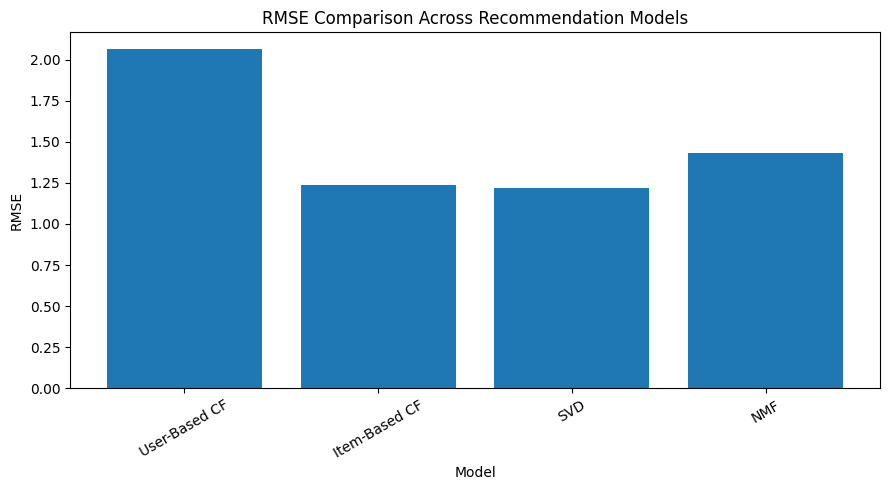

In [ ]:
import matplotlib.pyplot as plt

rmse_results = final_results.dropna(
    subset=["RMSE"]
)

plt.figure(figsize=(9, 5))

plt.bar(
    rmse_results["Model"],
    rmse_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison Across Recommendation Models")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

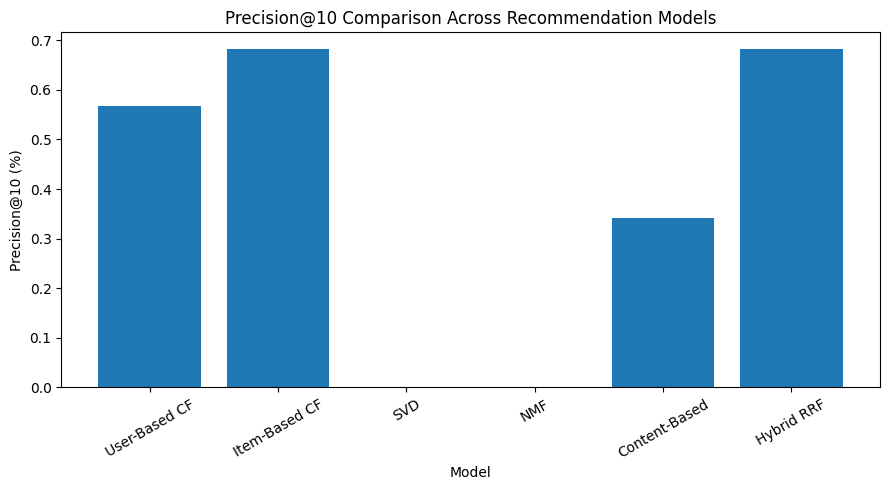

In [ ]:
precision_results = final_results.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    precision_results["Model"],
    precision_results["Precision@10 (%)"]
)

plt.ylabel("Precision@10 (%)")
plt.xlabel("Model")
plt.title("Precision@10 Comparison Across Recommendation Models")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Final Model Analysis

The recommendation system was evaluated using multiple recommendation approaches, including User-Based Collaborative Filtering, Item-Based Collaborative Filtering, Matrix Factorization, Content-Based Filtering, and a Hybrid RRF approach.

## 1. Rating Prediction Performance

Among the models evaluated for rating prediction, SVD achieved the lowest RMSE of 1.2166, indicating the lowest average prediction error among the tested rating-prediction models.

Item-Based Collaborative Filtering achieved an RMSE of 1.2342 and the lowest MAE of 0.6113 among the evaluated models.

User-Based Collaborative Filtering produced the highest RMSE of 2.0634 and MAE of 1.4941.

NMF achieved an RMSE of 1.4313 and MAE of 0.7751.

Therefore, SVD provided the best RMSE performance, while Item-Based Collaborative Filtering provided the best MAE performance in the current evaluation.

## 2. Top-N Recommendation Performance

Precision@10 was used to measure how many of the Top-10 recommended items were relevant to the user.

The results were:

- User-Based CF: 0.568%
- Item-Based CF: 0.682%
- SVD: 0.000%
- NMF: 0.000%
- Content-Based: 0.341%
- Hybrid RRF: 0.682%

Item-Based Collaborative Filtering and Hybrid RRF achieved the highest observed Precision@10 of 0.682%.

The Hybrid RRF model successfully combines the ranking information from Collaborative Filtering and Content-Based Filtering. It also avoids recommending items that the user has already rated in the training data.

## 3. Coverage Analysis

Coverage was also considered because a recommendation model may achieve good prediction accuracy while being unable to generate predictions for many user-item combinations.

The observed rating-prediction coverage was:

- User-Based CF: 10.2%
- Item-Based CF: 12.2%
- SVD: 100%
- NMF: 100%

Matrix Factorization models provided substantially higher coverage than the neighborhood-based Collaborative Filtering models in the current evaluation.

## 4. Overall Findings

The experiments demonstrate that different recommendation approaches have different strengths.

SVD achieved the lowest RMSE and therefore performed best for the current rating prediction evaluation.

Item-Based Collaborative Filtering achieved the lowest MAE and the highest observed Precision@10, tied with the Hybrid RRF model.

The Hybrid RRF model provides a useful combination of Collaborative Filtering and Content-Based recommendation signals. Its ranking-based fusion is particularly useful because the two recommendation approaches produced different candidate sets.

Content-Based Filtering provided an additional recommendation signal based on item metadata such as product titles, descriptions, and categories.

## 5. Evaluation Limitations

The current evaluation uses sampled test interactions and users rather than the complete test dataset for every model. Therefore, the reported metrics should be interpreted as experimental results rather than definitive production-level performance.

The RMSE and MAE values are not available for the Content-Based and Hybrid RRF models because these models were implemented primarily as Top-N recommendation systems rather than rating prediction models.

Precision@10 was evaluated using 88 users for the current experiments.

Future evaluation can use larger user samples and additional ranking metrics such as Recall@10, MAP@10, and NDCG@10 to provide a more comprehensive evaluation.

## 6. Conclusion

The experimental results show that no single recommendation technique dominates across every evaluation criterion.

SVD performed best in terms of RMSE, Item-Based Collaborative Filtering performed best in terms of MAE, and Item-Based CF and Hybrid RRF achieved the highest observed Precision@10.

The Hybrid RRF architecture demonstrates how multiple recommendation strategies can be combined to provide a more flexible personalized recommendation system.

In [ ]:
 from pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

results_path = RESULTS_DIR / "model_comparison.csv"

final_results.to_csv(
    results_path,
    index=False
)

print("Results saved to:")
print(results_path)

Results saved to:
c:\Users\Lenovo\amazon-recommendation-system\reports\model_results\model_comparison.csv


In [ ]:
coverage_path = RESULTS_DIR / "coverage_results.csv"

coverage_results.to_csv(
    coverage_path,
    index=False
)

print("Coverage results saved to:")
print(coverage_path)

Coverage results saved to:
c:\Users\Lenovo\amazon-recommendation-system\reports\model_results\coverage_results.csv


In [ ]:
hybrid_path = RESULTS_DIR / "hybrid_recommendations.csv"

hybrid_final.to_csv(
    hybrid_path,
    index=False
)

print("Hybrid recommendations saved to:")
print(hybrid_path)

Hybrid recommendations saved to:
c:\Users\Lenovo\amazon-recommendation-system\reports\model_results\hybrid_recommendations.csv


# Project Conclusion

This project developed a personalized recommendation system for Amazon Movies & TV and Video Games using multiple recommendation approaches.

The implemented approaches include:

- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Singular Value Decomposition (SVD)
- Non-Negative Matrix Factorization (NMF)
- TF-IDF Content-Based Filtering
- Hybrid Recommendation using Weighted Reciprocal Rank Fusion (RRF)

The experiments showed that different models perform well under different evaluation criteria.

SVD achieved the lowest RMSE among the evaluated rating-prediction models, while Item-Based Collaborative Filtering achieved the lowest MAE. Item-Based Collaborative Filtering and the Hybrid RRF model achieved the highest observed Precision@10 of 0.682%.

The Hybrid RRF model combines recommendations from Collaborative Filtering and Content-Based Filtering using ranking-based fusion. This approach allows both recommendation strategies to contribute even when their candidate recommendation sets are different.

The project also demonstrated the importance of considering coverage alongside prediction accuracy. Matrix Factorization models achieved substantially higher prediction coverage than the neighborhood-based Collaborative Filtering approaches in the current evaluation.

Overall, the project demonstrates a complete recommendation-system pipeline covering data preprocessing, exploratory data analysis, multiple recommendation algorithms, hybrid recommendation, evaluation, visualization, and result analysis.

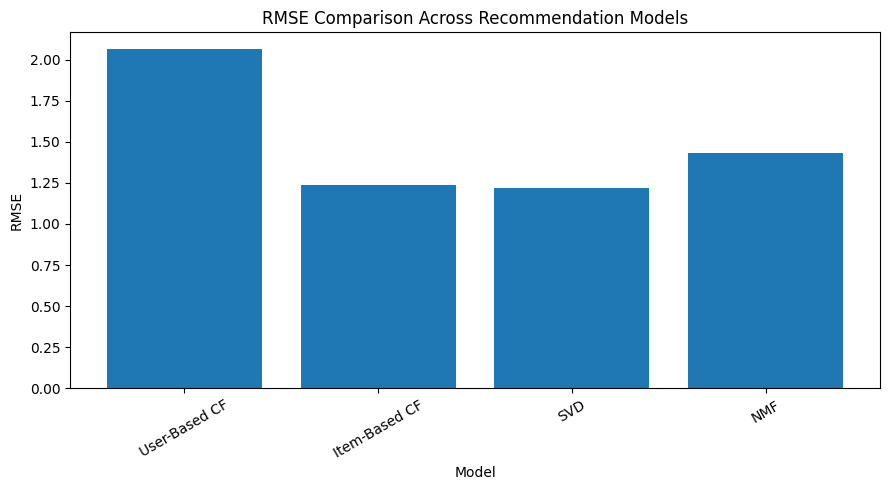

Saved: c:\Users\Lenovo\amazon-recommendation-system\reports\figures\rmse_comparison.png


In [ ]:
rmse_results = final_results.dropna(
    subset=["RMSE"]
)

plt.figure(figsize=(9, 5))

plt.bar(
    rmse_results["Model"],
    rmse_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison Across Recommendation Models")

plt.xticks(rotation=30)
plt.tight_layout()

rmse_path = PROJECT_ROOT / "reports" / "figures" / "rmse_comparison.png"

plt.savefig(
    rmse_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", rmse_path)

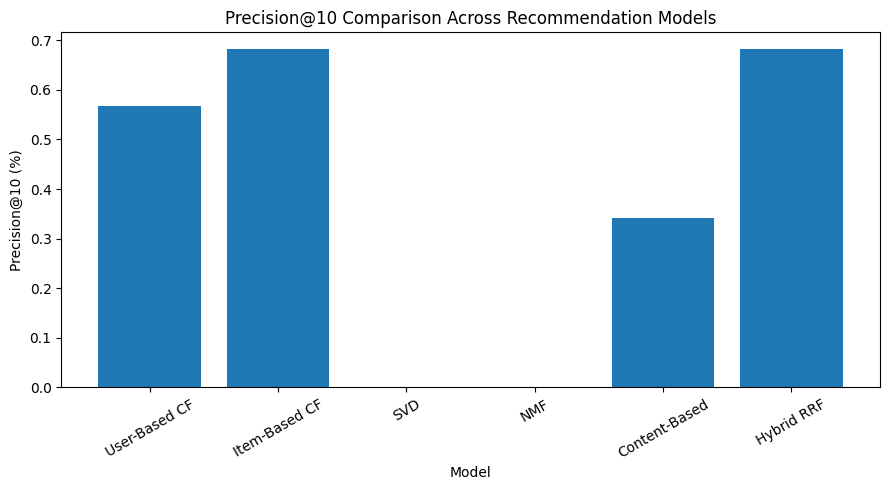

Saved: c:\Users\Lenovo\amazon-recommendation-system\reports\figures\precision_at_10_comparison.png


In [ ]:
precision_results = final_results.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    precision_results["Model"],
    precision_results["Precision@10 (%)"]
)

plt.ylabel("Precision@10 (%)")
plt.xlabel("Model")
plt.title("Precision@10 Comparison Across Recommendation Models")

plt.xticks(rotation=30)
plt.tight_layout()

precision_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "precision_at_10_comparison.png"
)

plt.savefig(
    precision_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", precision_path)